In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from myosuite.utils import gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.monitor import Monitor
import json
from stable_baselines3.common.vec_env import SubprocVecEnv


In [2]:
seed =  42
total_timesteps=5_000_000

FONCTIONS

- fonction d'entraînement (avec reward différents)

- fonction d'évalutation (distance parcourue, durée de survie, est ce qu'il est tombé)


In [31]:
def train_model(run_name, weighted_reward_keys, total_timesteps, seed):
    def make_env():
        env = gym.make('myoChallengeOslRunFixed-v0', weighted_reward_keys=weighted_reward_keys)
        return Monitor(env)

    train_env = make_vec_env(make_env, n_envs=8, seed=seed)
    eval_env = make_vec_env(make_env, n_envs=1, seed=seed + 1000)

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"./checkpoints/{run_name}/",
        log_path=f"./eval_logs/{run_name}/",
        eval_freq=10_000 // 8,
        n_eval_episodes=10,
        deterministic=True,
    )

    checkpoint_callback = CheckpointCallback(
        save_freq=1_000_000 // 8,   # sauvegarde tous les 1M pas (÷8 car 8 envs parallèles)
        save_path=f"./checkpoints/{run_name}/",
        name_prefix=run_name,
    )

    model = PPO("MlpPolicy", train_env, verbose=1, seed=seed, tensorboard_log="./tb_logs/")
    model.learn(
        total_timesteps=total_timesteps,
        callback=[eval_callback, checkpoint_callback],
        tb_log_name=run_name,
    )
    model.save(f"./checkpoints/{run_name}_final")
    return model

In [7]:
def evaluate_model(model, n_episodes=20, seed=999):
    """
    Fait tourner le modèle sur n_episodes et mesure des choses
    indépendantes du reward utilisé pour l'entraîner :
    - distance parcourue
    - durée de survie (nombre de pas avant chute/fin)
    - est-ce qu'il est tombé ?
    """
    env = gym.make('myoChallengeOslRunFixed-v0', seed=seed)

    distances, lengths, falls = [], [], []

    for ep in range(n_episodes):
        obs, info = env.reset()
        terminated, truncated = False, False
        steps = 0

        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            steps += 1

        # position finale en y = distance parcourue (le score officiel de la tâche)
        distances.append(env.unwrapped.obs_dict["model_root_pos"][1])
        lengths.append(steps)
        falls.append(env.unwrapped._get_fallen_condition())

    env.close()

    return {
        "distance_mean": float(np.mean(distances)),
        "distance_std": float(np.std(distances)),
        "ep_len_mean": float(np.mean(lengths)),
        "fall_rate": float(np.mean(falls)),  # proportion d'épisodes où l'agent tombe
    }

In [6]:
def plot_training_comparison(run_names, eval_logs_dir="./eval_logs", smooth_window=5):
    """
    Compare la progression de plusieurs runs d'entraînement, à partir
    des fichiers evaluations.npz générés automatiquement par EvalCallback.

    run_names : liste de noms de run, ex. ["osl_default_5M", "osl_shaped_5M"]
    smooth_window : taille de la fenêtre de moyenne glissante pour lisser les courbes
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for run_name in run_names:
        npz_path = f"{eval_logs_dir}/{run_name}/evaluations.npz"
        try:
            data = np.load(npz_path)
        except FileNotFoundError:
            print(f"[!] Pas de fichier trouvé pour {run_name} à {npz_path}")
            continue

        timesteps = data["timesteps"]
        results = data["results"]        # shape (n_evals, n_eval_episodes) -> reward par épisode
        ep_lengths = data["ep_lengths"]  # shape (n_evals, n_eval_episodes)

        # Moyenne + écart-type par point d'évaluation (across les n_eval_episodes)
        reward_mean = results.mean(axis=1)
        reward_std = results.std(axis=1)
        len_mean = ep_lengths.mean(axis=1)

        # --- Plot 1 : reward moyen au cours de l'entraînement ---
        axes[0].plot(timesteps, reward_mean, label=run_name)
        axes[0].fill_between(timesteps, reward_mean - reward_std, reward_mean + reward_std, alpha=0.2)

        # --- Plot 2 : durée moyenne des épisodes (proxy de stabilité/survie) ---
        axes[1].plot(timesteps, len_mean, label=run_name)

        # --- Plot 3 : écart-type du reward (proxy de "consistance" de la policy) ---
        axes[2].plot(timesteps, reward_std, label=run_name)

    axes[0].set_title("Reward moyen (éval) au cours de l'entraînement")
    axes[0].set_xlabel("Pas d'entraînement")
    axes[0].set_ylabel("Reward moyen ± écart-type")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_title("Durée moyenne des épisodes (survie)")
    axes[1].set_xlabel("Pas d'entraînement")
    axes[1].set_ylabel("Nombre de pas avant fin d'épisode")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].set_title("Écart-type du reward (variance/consistance)")
    axes[2].set_xlabel("Pas d'entraînement")
    axes[2].set_ylabel("Écart-type")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_comparison.png", dpi=150)
    plt.show()

    return fig


TEST RAPIDE 

In [34]:
model_test = train_model(
    run_name="TEST_pipeline_check",
    weighted_reward_keys={"sparse": 1, "solved": 10, "act_reg": -0.1, "pain": -0.5},
    total_timesteps=50_000,   # quelques secondes/minutes, pas des heures
    seed=seed,
)


Using cpu device
Logging to ./tb_logs/TEST_pipeline_check_10
Eval num_timesteps=10000, episode_reward=45.83 +/- 51.87
Episode length: 147.80 +/- 18.02
---------------------------------
| eval/              |          |
|    mean_ep_length  | 148      |
|    mean_reward     | 45.8     |
| time/              |          |
|    total_timesteps | 10000    |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 179      |
|    ep_rew_mean     | -27      |
| time/              |          |
|    fps             | 403      |
|    iterations      | 1        |
|    time_elapsed    | 40       |
|    total_timesteps | 16384    |
---------------------------------
Eval num_timesteps=20000, episode_reward=77.84 +/- 61.46
Episode length: 154.00 +/- 15.42
-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 154         |
|    mean_reward          | 77.8 

{'distance_mean': 14.254517659302994, 'distance_std': 0.06481339934244179, 'ep_len_mean': 171.0, 'fall_rate': 1.0}


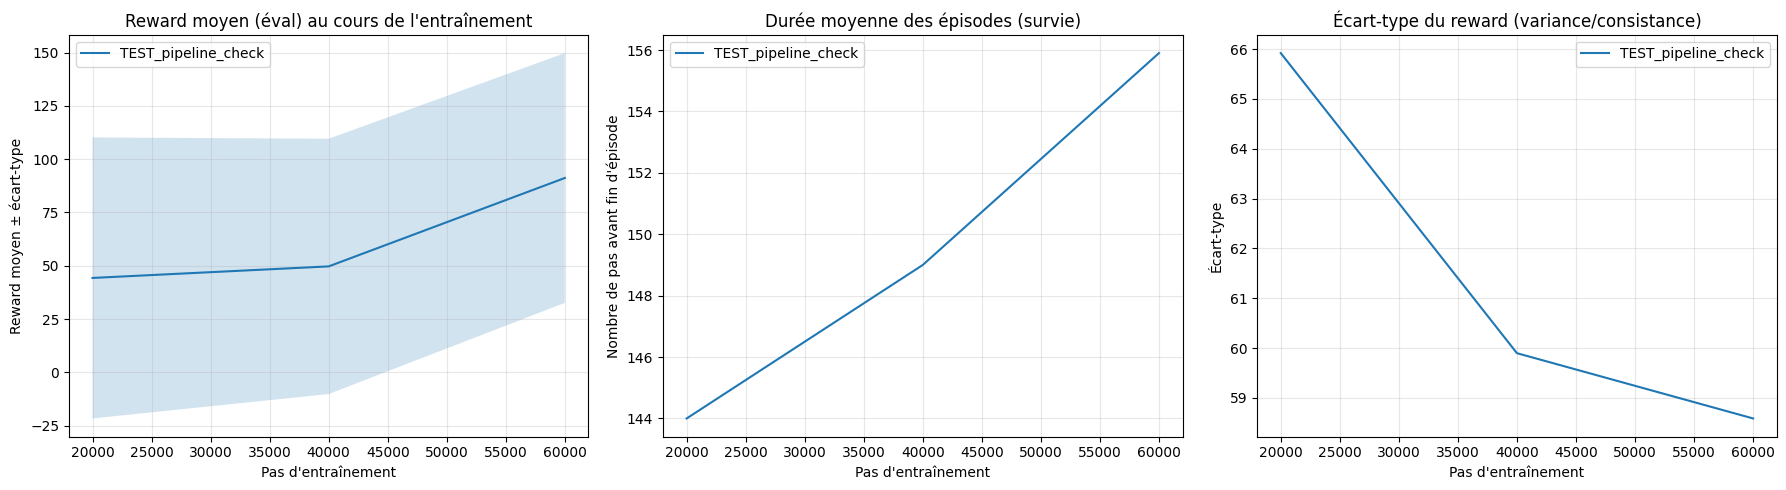

[20000 40000 60000]
(3, 10)


In [11]:
# vérifie que evaluate_model fonctionne aussi
test_results = evaluate_model(model_test, n_episodes=2)
print(test_results)

plot_training_comparison(["TEST_pipeline_check"])

data = np.load("./eval_logs/TEST_pipeline_check/evaluations.npz")
print(data["timesteps"])
print(data["results"].shape)

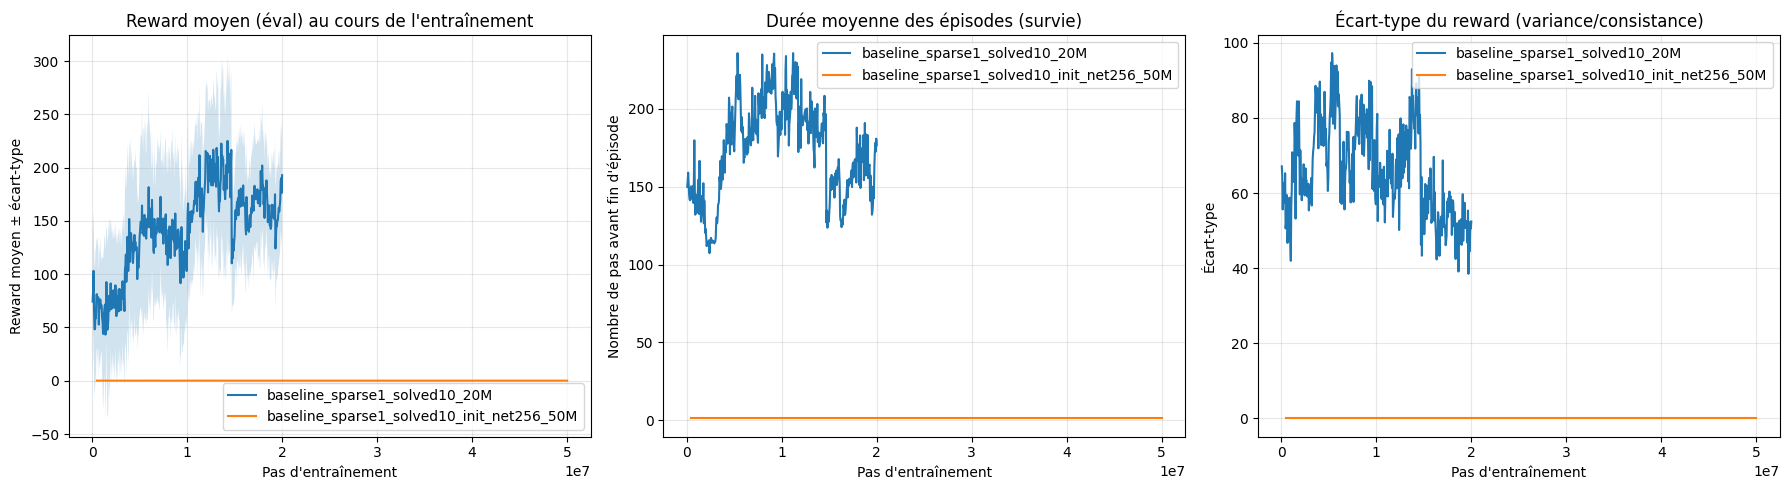

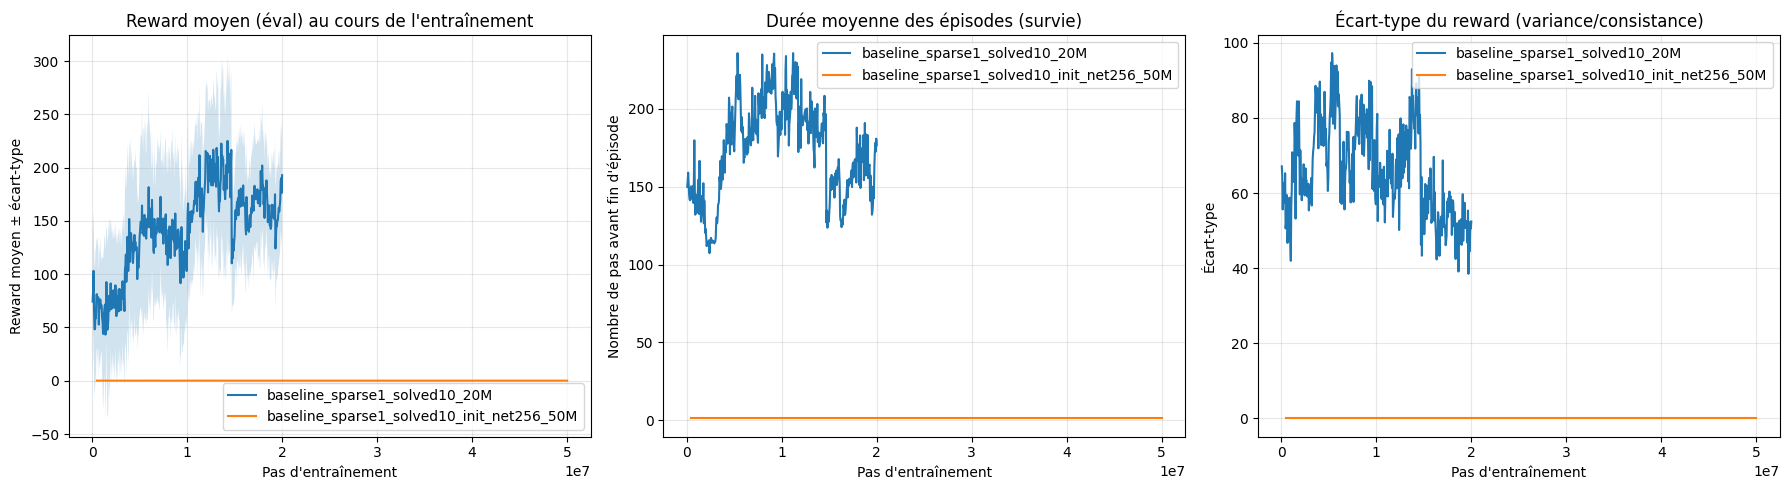

In [8]:
plot_training_comparison(["baseline_sparse1_solved10_20M", "baseline_sparse1_solved10_init_net256_50M"])


In [1]:
import os
import numpy as np
import imageio
from tqdm import tqdm
from myosuite.utils import gym
from stable_baselines3 import PPO

run_name = "baseline_sparse1_solved10_init_net256_50M"
weighted_reward_keys = {"sparse": 1, "solved": 10, "act_reg": -0.5, "pain": -2.0}

# Utilise le "best_model" si dispo (meilleur checkpoint selon EvalCallback),
# sinon retombe sur le modèle final
best_model_path = f"./checkpoints/{run_name}/best_model.zip"
final_model_path = f"./checkpoints/{run_name}_final.zip"
model_path = best_model_path if os.path.exists(best_model_path) else final_model_path
print(f"Chargement du modèle depuis : {model_path}")

env = gym.make('myoChallengeOslRunFixed-v0', weighted_reward_keys=weighted_reward_keys)
model = PPO.load(model_path, env=env)

frames = []
all_rewards = []

for ep in tqdm(range(5)):  # 5 épisodes, terrain randomisé par défaut
    obs, info = env.reset()
    ep_rewards = []
    terminated, truncated = False, False
    step_count = 0
    max_steps = 1000  # garde-fou, au cas où l'agent ne tombe jamais

    while not (terminated or truncated) and step_count < max_steps:
        action, _ = model.predict(obs, deterministic=True)

        # transparence du groupe de géométries 1 (comme dans le tutoriel officiel)
        geom_1_indices = np.where(env.unwrapped.mj_model.geom_group == 1)
        env.unwrapped.mj_model.geom_rgba[geom_1_indices, 3] = 0

        frame = env.unwrapped.mj_renderer.render_offscreen(
            width=400, height=400, camera_id=1
        )
        frames.append(frame)

        obs, reward, terminated, truncated, info = env.step(action)
        ep_rewards.append(reward)
        step_count += 1

    all_rewards.append(np.sum(ep_rewards))
    print(f"Episode {ep}: reward={np.sum(ep_rewards):.2f}, steps={step_count}")

env.close()

os.makedirs('videos', exist_ok=True)
imageio.mimwrite(f'videos/{run_name}.mp4', frames, fps=1.0 / env.unwrapped.dt)
print(f"Average reward: {np.mean(all_rewards):.2f} over {len(all_rewards)} episodes")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


MyoSuite:> Registering Myo Envs
Chargement du modèle depuis : ./checkpoints/baseline_sparse1_solved10_init_net256_50M/best_model.zip
    MyoSuite: A contact-rich simulation suite for musculoskeletal motor control
        Vittorio Caggiano, Huawei Wang, Guillaume Durandau, Massimo Sartori, Vikash Kumar
        L4DC-2019 | https://sites.google.com/view/myosuite
    


c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
 20%|██        | 1/5 [00:15<01:01, 15.45s/it]

...

 80%|████████  | 4/5 [01:01<00:15, 15.81s/it]

Episode 3: reward=79.20, steps=144


100%|██████████| 5/5 [01:19<00:00, 15.83s/it]

Episode 4: reward=108.71, steps=148


Average reward: 90.11 over 5 episodes


Entrainements

In [ ]:
model_default = train_model(
    run_name="osl_default_5M",
    weighted_reward_keys={"sparse": 1, "solved": 10},
    total_timesteps=total_timesteps,
    seed=seed,
)

In [ ]:

model_shaped = train_model(
    run_name="osl_shaped_5M",
    weighted_reward_keys={"sparse": 1, "solved": 10, "act_reg": -0.1, "pain": -0.5},
    total_timesteps=total_timesteps,
    seed=seed,
)


Evaluer

In [ ]:
plot_training_comparison(["osl_default_5M", "osl_shaped_5M"])

In [ ]:
results = {
    "default": evaluate_model(model_default),
    "shaped": evaluate_model(model_shaped),
}

# Sauvegarde simple en JSON, pour pouvoir comparer facilement après coup
with open("comparison_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
